In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, get_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.multiclass import OneVsRestClassifier

In [3]:
df = pd.read_csv(r"..\..\oblig3_og_4\student_performance.csv", delimiter=";")

In [4]:
df_features = pd.DataFrame(StandardScaler().fit_transform(df.drop('Target', axis=1)), columns=df.drop('Target', axis=1).columns)
df_targets = pd.Series(np.array(LabelEncoder().fit_transform(df['Target'])))

In [6]:
global_random_state = 15

scoring = {
    'accuracy': get_scorer('accuracy'),
    'precision': make_scorer(precision_score, average='macro', zero_division=1.0),
    'recall': make_scorer(recall_score, average='macro', zero_division=1.0),
    'f1': make_scorer(f1_score, average='macro'),  
}

def evaluate(estimator, X, y):
    scores = {}
    for (name,scorer) in scoring.items():
        scores[name] = scorer(estimator, X, y) 
    return scores

def train(features, targets, estimator, params, scoring=scoring, refit='f1', random_state=global_random_state, outer_splits=5, inner_splits=4):

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=global_random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=global_random_state)

    scores_train = []
    scores_test = []
    estimators = []
    cv_results = []

    for (train_index, test_index) in outer_cv.split(features, targets):
        
        grid = GridSearchCV(
            estimator,
            params, 
            scoring=scoring, 
            refit=refit,
            error_score='raise', 
            cv=inner_cv)
        grid.fit(features.iloc[train_index], targets.iloc[train_index])        
        
        evaluation_train = evaluate(grid, features.iloc[train_index], targets.iloc[train_index])
        evaluation_test = evaluate(grid, features.iloc[test_index], targets.iloc[test_index])
        
        scores_train.append(evaluation_train)
        scores_test.append(evaluation_test)
        
        estimators.append(grid.best_estimator_)
        cv_results.append(pd.DataFrame(grid.cv_results_))
        print("*")

    return estimators, pd.DataFrame(scores_train), pd.DataFrame(scores_test), pd.concat(cv_results, names=['test_split'], keys=range(outer_splits))

def print_estimators(estimators):
    for estimatior in estimators:
        print(estimatior)

In [6]:
gb_params = {
    "n_estimators": [250],
    "learning_rate": [0.1],
    'min_samples_split': [6],
    'max_depth': [2],
}
gb_estimators_final, gb_scores_train_final, gb_scores_test_final, gb_cv_results_final = train(df_features, df_targets,
    GradientBoostingClassifier(random_state=global_random_state),
    gb_params, outer_splits=5, inner_splits=4)

*
*
*
*
*


In [11]:
def create_model_2(optimizer='adam', activation='swish', hidden_neurons=75, layers=2, dropout=0.1, reduction_factor=0.5, learning_rate=0.001):
    input = Input(shape=(36,))
    x = (Dense(hidden_neurons, activation=activation))(input)
    if(layers > 0):
        hidden_neurons = hidden_neurons*reduction_factor
        if(hidden_neurons >= 1):
            x = (Dense(int(hidden_neurons), activation=activation))(x) + (Dense(int(hidden_neurons), activation=activation))(x)     
    if(layers > 1):
        hidden_neurons = hidden_neurons*reduction_factor
        if(hidden_neurons >= 1):
            x = (Dense(int(hidden_neurons), activation=activation))(x) + (Dense(int(hidden_neurons), activation=activation))(input)
    if(dropout > 0):
        x = (Dropout(dropout))(x)
    x = (Dense(3, activation='softmax'))(x)
    model = Model(inputs=input, outputs=x)   
    if(optimizer == 'adam'):
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

keras_model = KerasClassifier(model=create_model_2, verbose=0)

keras_class_param = {
    'batch_size': [10],
    'epochs': [100],
    'model__hidden_neurons': [75],
    'model__layers': [0],
    'model__reduction_factor': [0.5],
    'model__optimizer': ['rmsprop'],
    'model__activation': ['elu'],
    'model__learning_rate': [0.001],
    'model__dropout':[0.4],
}
keras_model_estimators_final, keras_model_scores_train_final, keras_model_scores_test_final, keras_model_cv_results_final = train(df_features, df_targets, keras_model, keras_class_param, outer_splits=5, inner_splits=4)

*
*
*
*
*


In [12]:
slutt_resultat = pd.DataFrame({
    'Metric': ['Accuracy:','Precision:','Recall:', 'F1:'],
    'Gradient Boosting Train': [gb_scores_train_final['accuracy'].mean(),gb_scores_train_final['precision'].mean(), gb_scores_train_final['recall'].mean(), gb_scores_train_final['f1'].mean()],
    'Gradient Boosting Test': [gb_scores_test_final['accuracy'].mean(),gb_scores_test_final['precision'].mean(), gb_scores_test_final['recall'].mean(), gb_scores_test_final['f1'].mean()],
    'Keras Model Train': [keras_model_scores_train_final['accuracy'].mean(),keras_model_scores_train_final['precision'].mean(), keras_model_scores_train_final['recall'].mean(), keras_model_scores_train_final['f1'].mean()],
    'Keras Model Test': [keras_model_scores_test_final['accuracy'].mean(),keras_model_scores_test_final['precision'].mean(), keras_model_scores_test_final['recall'].mean(), keras_model_scores_test_final['f1'].mean()],
    })
slutt_resultat.set_index('Metric', inplace=True)
slutt_resultat

,Gradient Boosting Train,Gradient Boosting Test,Keras Model Train,Keras Model Test
Metric,,,,
Accuracy:,0.833352,0.781649,0.798599,0.765823
Precision:,0.809979,0.735333,0.760310,0.708096
Recall:,0.767911,0.701727,0.715176,0.671355
F1:,0.783210,0.712367,0.728171,0.679690


### Sammenligning GradientBoosting og Keras Model

- Som vi ser ut i fra resultatene så scorer GradiensBoosting modellen bedre for alle metricene enn Keras Model.

- Når vi ser på forskjellene mellom train og test resultatene for modellen ser vi at GradientBoosting modellen har noen mere overfiting enn det Keras Model har. Men disse forskjellene er ikke veldig store, og ut ifra helheten til prestasjonene til modellen vil jeg si at GradientBoosting modellen er den gir best resultat.

- Som påpekt i vurderingen for både supervised og neural nettwork modellene ser ut som den største begrensingen til modellene er utfordringer med å oppdage alle reelle positive tilfeller for target klassene.

- I forhold til tuning av modellen er det viktig å påpek at jeg hadde betydelig større begrensinger ved tuning av neural nettwork modellen og det er mye mulig at jeg med sterkere hardware kunne ha oppnådd bedre modeller og resultater meg neural nettwork.

In [8]:
def split_targets_and_features(data):
    targets = data['Target']
    features = pd.DataFrame(StandardScaler().fit_transform(data.drop("Target", axis=1)), columns=data.drop("Target", axis=1).columns)
    
    return [features, targets]

def split_dataset(data):
    data['Target'] = pd.Series(np.array(LabelEncoder().fit_transform(data['Target'])))
    train = data.groupby("Target", group_keys=False)[df.columns].sample(frac=0.8)
    test = data.drop(train.index)
    train = split_targets_and_features(train)
    test = split_targets_and_features(test)

    return train, test

slutt_train, slutt_test = split_dataset(df)

In [9]:
gb_params = {
    "n_estimators": [250],
    "learning_rate": [0.1],
    'min_samples_split': [6],
    'max_depth': [2],   
}
gb_model = GradientBoostingClassifier(random_state=global_random_state, max_depth=2, min_samples_split=6, n_estimators=250, learning_rate=0.1)
gb_model.fit(slutt_train[0], slutt_train[1])

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,6
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


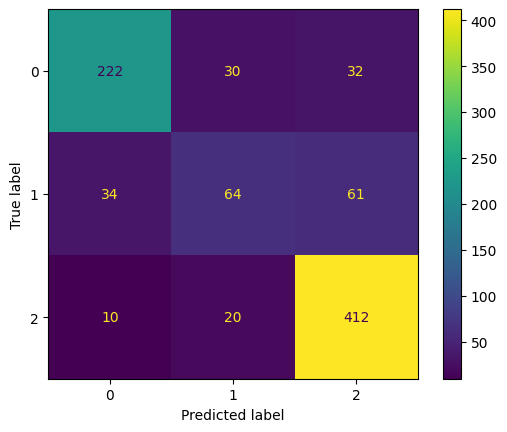

In [11]:
ConfusionMatrixDisplay.from_estimator(gb_model, slutt_test[0], slutt_test[1])

0       0
4       2
8       2
10      2
13      2
       ..
4367    2
4370    2
4383    2
4390    2
4402    1
Name: Target, Length: 885, dtype: int64

c:\Users\hallo\Documents\GitHub\praktisk-maskinlering\.venv\Lib\site-packages\sklearn\metrics\_plot\roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
c:\Users\hallo\Documents\GitHub\praktisk-maskinlering\.venv\Lib\site-packages\sklearn\metrics\_plot\roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
c:\Users\hallo\Documents\GitHub\praktisk-maskinlering\.venv\Lib\site-packages\sklearn\metrics\_plot\roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


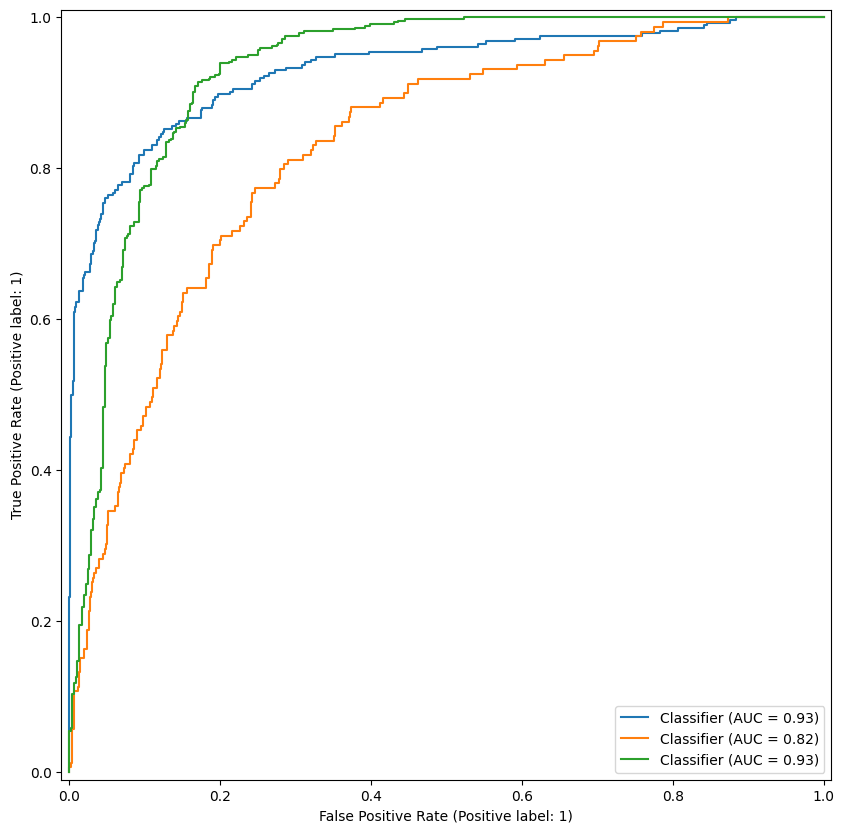

In [24]:
#model = OneVsRestClassifier(gb_model).fit(slutt_train[0], slutt_train[1]).predict_proba(slutt_test[0])



fig, ax = plt.subplots(figsize=(10, 10))

for class_id in range(3):
    RocCurveDisplay.from_predictions(
    y_true=(slutt_test[1] == class_id),
    y_pred=gb_model.predict_proba(slutt_test[0])[:, class_id],
    ax=ax
    
    )

https://x.com/i/grok/share/OWIOJSvsu0cvVaQiwEKwGQ2yF